# 03A: K-Means Stock Clustering

## Objective
Use K-Means to cluster S&P 500 stocks with a reusable Kaggle data pipeline and cached features.

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn kagglehub

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import kagglehub

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Shared paths
cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = DATA_DIR / 'sp500_raw.csv'
FEATURE_CACHE = DATA_DIR / 'clustering_features_latest.csv'

print(f'DATA_DIR: {DATA_DIR}')
print(f'GRAPH_DIR: {GRAPH_DIR}')

DATA_DIR: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data
GRAPH_DIR: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\graph


In [3]:
def create_clustering_features(stock_data: pd.DataFrame) -> pd.DataFrame:
    stock_data = stock_data.sort_values('date').reset_index(drop=True).copy()
    stock_data['volatility'] = stock_data['close'].pct_change().rolling(20).std()
    stock_data['avg_return'] = stock_data['close'].pct_change().rolling(20).mean()
    stock_data['avg_volume'] = stock_data['volume'].rolling(20).mean()
    stock_data['volume_volatility'] = stock_data['volume'].rolling(20).std() / stock_data['volume'].rolling(20).mean()
    stock_data['momentum'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['close']
    stock_data['trend_strength'] = (stock_data['close'] - stock_data['low']) / (stock_data['high'] - stock_data['low'])
    stock_data['price_level'] = stock_data['close'] / 100
    stock_data['volume_to_price_ratio'] = stock_data['volume'] / stock_data['close']
    return stock_data

def load_raw_data() -> pd.DataFrame:
    if RAW_CACHE.exists():
        print('[CACHE] Using local raw cache')
        return pd.read_csv(RAW_CACHE)

    print('[DOWNLOAD] Fetching Kaggle dataset...')
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError('No CSV found in downloaded dataset')

    df = pd.read_csv(os.path.join(path, csv_files[0]))
    df.to_csv(RAW_CACHE, index=False)
    print(f'[CACHE] Saved raw cache: {RAW_CACHE.name}')
    return df

def load_feature_table(data: pd.DataFrame) -> pd.DataFrame:
    if FEATURE_CACHE.exists():
        print('[CACHE] Using local feature cache')
        return pd.read_csv(FEATURE_CACHE)

    print('[BUILD] Creating clustering features...')
    processed = pd.concat([
        create_clustering_features(data[data['Name'] == stock])
        for stock in data['Name'].unique()
    ], ignore_index=True)

    clustering_data = processed.sort_values('date').drop_duplicates('Name', keep='last')
    clustering_data = clustering_data.dropna().reset_index(drop=True)
    clustering_data.to_csv(FEATURE_CACHE, index=False)
    print(f'[CACHE] Saved feature cache: {FEATURE_CACHE.name}')
    return clustering_data

data = load_raw_data()
clustering_data = load_feature_table(data)

feature_cols = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility',
    'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio'
]

X = clustering_data[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Samples: {len(clustering_data)} | Features: {len(feature_cols)}')

[DOWNLOAD] Fetching Kaggle dataset...
[CACHE] Saved raw cache: sp500_raw.csv
[BUILD] Creating clustering features...
[CACHE] Saved feature cache: clustering_features_latest.csv
Samples: 505 | Features: 9


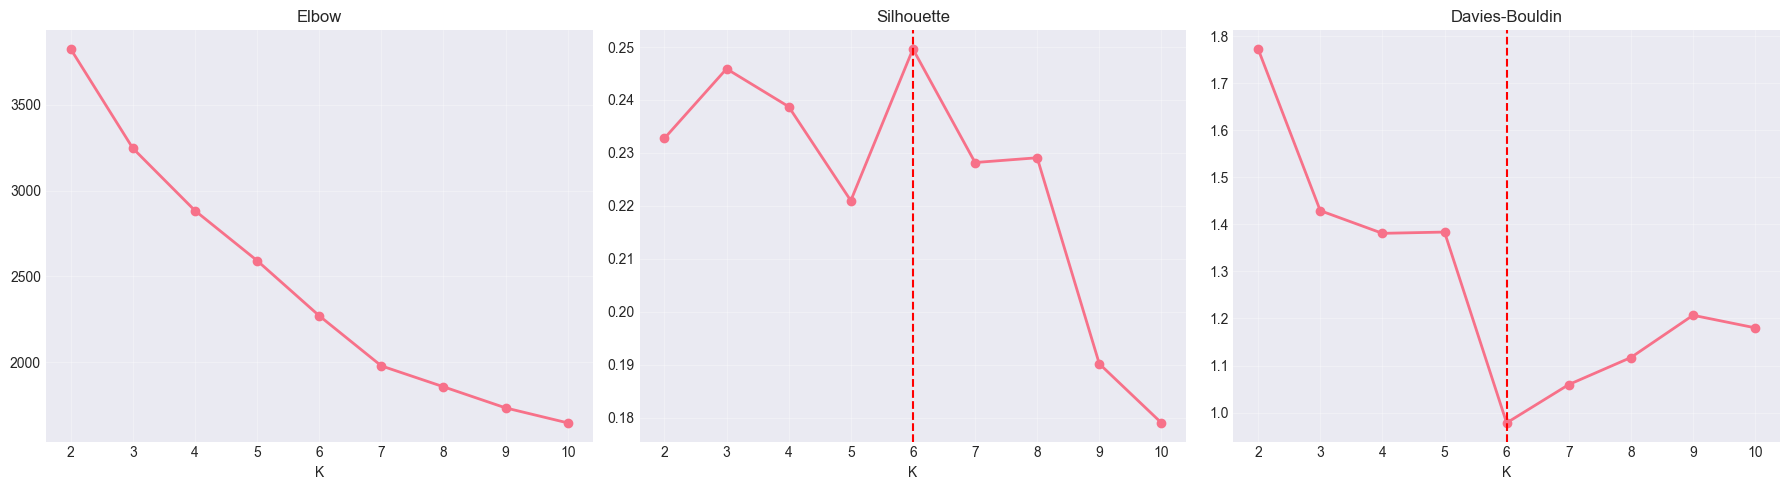

best_k_sil=6, best_k_db=6, optimal_k=6


In [4]:
k_values = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

best_k_sil = list(k_values)[int(np.argmax(sil_scores))]
best_k_db = list(k_values)[int(np.argmin(db_scores))]
optimal_k = best_k_sil

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(k_values), inertias, 'o-', linewidth=2); axes[0].set_title('Elbow')
axes[1].plot(list(k_values), sil_scores, 'o-', linewidth=2); axes[1].axvline(best_k_sil, color='red', linestyle='--'); axes[1].set_title('Silhouette')
axes[2].plot(list(k_values), db_scores, 'o-', linewidth=2); axes[2].axvline(best_k_db, color='red', linestyle='--'); axes[2].set_title('Davies-Bouldin')
for ax in axes:
    ax.set_xlabel('K'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(GRAPH_DIR / '03A_01_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'best_k_sil={best_k_sil}, best_k_db={best_k_db}, optimal_k={optimal_k}')

In [5]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clustering_data['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_summary = clustering_data.groupby('cluster')[feature_cols].mean().round(4)
cluster_sizes = clustering_data['cluster'].value_counts().sort_index()

sil = silhouette_score(X_scaled, clustering_data['cluster'])
dbi = davies_bouldin_score(X_scaled, clustering_data['cluster'])

print('Cluster sizes:')
print(cluster_sizes)
print(f'Silhouette={sil:.4f}, Davies-Bouldin={dbi:.4f}')
display(cluster_summary)

cluster_summary.to_csv(DATA_DIR / '03A_cluster_feature_summary.csv')
clustering_data[['Name', 'cluster'] + feature_cols].to_csv(DATA_DIR / '03A_stock_cluster_assignments.csv', index=False)

Cluster sizes:
cluster
0    286
1    139
2      4
3      1
4     71
5      4
Name: count, dtype: int64
Silhouette=0.2496, Davies-Bouldin=0.9782


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0154,-0.0021,3.768906e+06,0.3594,-0.0433,0.0253,0.1739,1.0233,7.397786e+04
1,0.0208,0.0021,4.968325e+06,0.4488,0.0383,0.0345,0.4760,1.0404,1.257531e+05
2,0.0249,-0.0044,8.231132e+07,0.4276,-0.0855,0.0273,0.2022,0.1722,4.838050e+06
3,0.0327,-0.0162,3.924752e+07,0.3542,-0.2864,0.1246,0.2500,0.0289,2.462799e+07
4,0.0240,-0.0058,5.580841e+06,0.5299,-0.1143,0.0413,0.2162,0.7349,2.046012e+05
5,0.0179,0.0005,2.729800e+06,0.4238,0.0092,0.0321,0.1980,13.5086,2.509195e+03


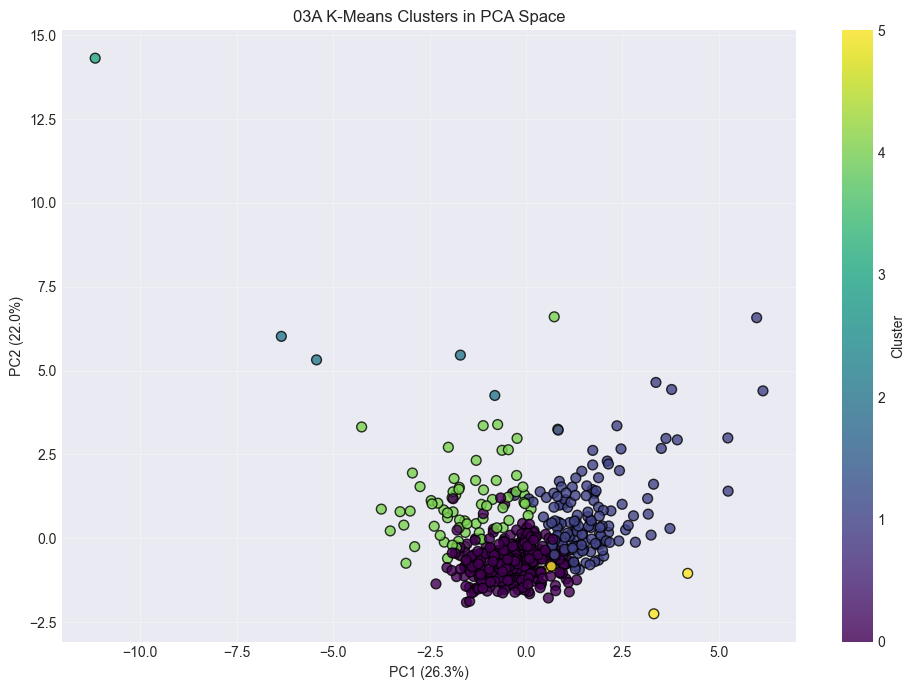

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering_data['cluster'], cmap='viridis', s=50, edgecolor='black', alpha=0.8)
ax.set_title('03A K-Means Clusters in PCA Space')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(alpha=0.3)
plt.colorbar(sc, label='Cluster')
plt.tight_layout()
plt.savefig(GRAPH_DIR / '03A_02_pca_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation and Financial Interpretation
Use this section to assess statistical quality and practical finance meaning of clusters.

- Statistical checks: cluster concentration, feature differentiation profile.
- Finance checks: return-risk tradeoff, momentum dispersion, and liquidity context.
- Portfolio use: identify aggressive, defensive, and balanced baskets by regime.

=== Cluster Composition ===


,count,weight_pct
cluster,,
0,286,56.63
1,139,27.52
2,4,0.79
3,1,0.20
4,71,14.06
5,4,0.79


=== Cluster Feature Profile (mean) ===


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0154,-0.0021,3.768906e+06,0.3594,-0.0433,0.0253,0.1739,1.0233,7.397786e+04
1,0.0208,0.0021,4.968325e+06,0.4488,0.0383,0.0345,0.4760,1.0404,1.257531e+05
2,0.0249,-0.0044,8.231132e+07,0.4276,-0.0855,0.0273,0.2022,0.1722,4.838050e+06
3,0.0327,-0.0162,3.924752e+07,0.3542,-0.2864,0.1246,0.2500,0.0289,2.462799e+07
4,0.0240,-0.0058,5.580841e+06,0.5299,-0.1143,0.0413,0.2162,0.7349,2.046012e+05
5,0.0179,0.0005,2.729800e+06,0.4238,0.0092,0.0321,0.1980,13.5086,2.509195e+03


=== Risk-Return Lens ===


,avg_return,volatility,momentum,price_range,return_to_risk
cluster,,,,,
0,-0.0021,0.0154,-0.0433,0.0253,-0.1377
1,0.0021,0.0208,0.0383,0.0345,0.0989
2,-0.0044,0.0249,-0.0855,0.0273,-0.1766
3,-0.0162,0.0327,-0.2864,0.1246,-0.4963
4,-0.0058,0.0240,-0.1143,0.0413,-0.2421
5,0.0005,0.0179,0.0092,0.0321,0.0273


[Insight] Cluster 1 has the strongest return-to-risk proxy in this snapshot.
[Insight] Cluster 0 is the most defensive regime by realized volatility.


C:\Users\25012923g\AppData\Local\Temp\ipykernel_20340\750956462.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')


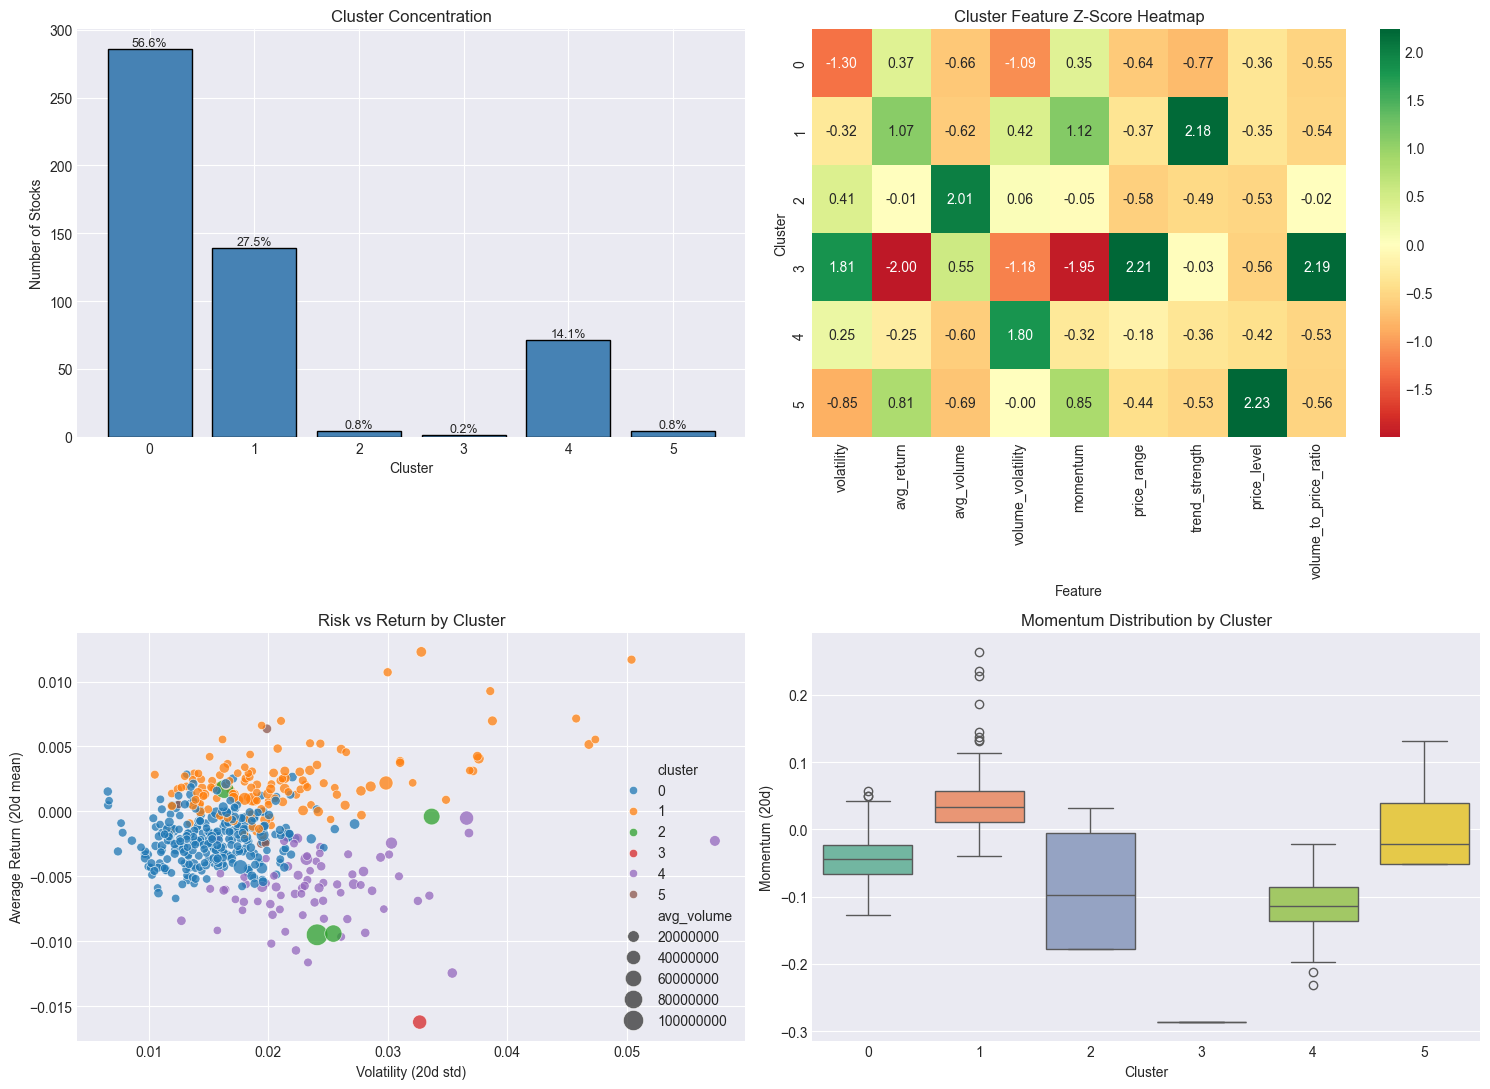

Saved evaluation dashboard: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\graph\03A_03_evaluation_dashboard.png


In [7]:
method_tag = '03A'
cluster_col = 'cluster'
eval_df = clustering_data.copy()

size_tbl = eval_df[cluster_col].value_counts().sort_index().rename('count').to_frame()
size_tbl['weight_pct'] = 100 * size_tbl['count'] / size_tbl['count'].sum()

profile_mean = eval_df.groupby(cluster_col)[feature_cols].mean()
profile_std = profile_mean.std(ddof=0).replace(0, np.nan)
profile_z = ((profile_mean - profile_mean.mean()) / profile_std).fillna(0.0)

risk_cols = ['avg_return', 'volatility', 'momentum', 'price_range']
risk_view = profile_mean[risk_cols].copy()
risk_view['return_to_risk'] = risk_view['avg_return'] / risk_view['volatility'].replace(0, np.nan)

print('=== Cluster Composition ===')
display(size_tbl.round(2))

print('=== Cluster Feature Profile (mean) ===')
display(profile_mean.round(4))

print('=== Risk-Return Lens ===')
display(risk_view.round(4))

if len(risk_view) >= 2:
    best_rr = risk_view['return_to_risk'].idxmax()
    defensive = risk_view['volatility'].idxmin()
    print(f'[Insight] Cluster {best_rr} has the strongest return-to-risk proxy in this snapshot.')
    print(f'[Insight] Cluster {defensive} is the most defensive regime by realized volatility.')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

bars = axes[0, 0].bar(size_tbl.index.astype(str), size_tbl['count'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Cluster Concentration')
axes[0, 0].set_xlabel('Cluster'); axes[0, 0].set_ylabel('Number of Stocks')
for i, b in enumerate(bars):
    pct = size_tbl['weight_pct'].iloc[i]
    axes[0, 0].text(b.get_x() + b.get_width()/2, b.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

sns.heatmap(profile_z, cmap='RdYlGn', center=0, annot=True, fmt='.2f', ax=axes[0, 1])
axes[0, 1].set_title('Cluster Feature Z-Score Heatmap')
axes[0, 1].set_xlabel('Feature'); axes[0, 1].set_ylabel('Cluster')

sns.scatterplot(data=eval_df, x='volatility', y='avg_return', hue=cluster_col, size='avg_volume', sizes=(35, 240),
                alpha=0.75, palette='tab10', ax=axes[1, 0])
axes[1, 0].set_title('Risk vs Return by Cluster')
axes[1, 0].set_xlabel('Volatility (20d std)'); axes[1, 0].set_ylabel('Average Return (20d mean)')

sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Momentum Distribution by Cluster')
axes[1, 1].set_xlabel('Cluster'); axes[1, 1].set_ylabel('Momentum (20d)')

plt.tight_layout()
dashboard_path = GRAPH_DIR / f'{method_tag}_03_evaluation_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved evaluation dashboard: {dashboard_path}')